# Models used to make predictions 使用模型

- XGBoost Classifier
- GridSearchCV for Hyperparameter tuning
- AutoGluon 多个模型分析

In [12]:
!PIP install folium
!pip install --upgrade pandas


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\HW\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\HW\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import math
import folium
import numpy as np
from IPython.display import Markdown
from sklearn.preprocessing import LabelEncoder

def bold(string):
    display(Markdown(string))

import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [2]:
# rc = {
#     "axes.facecolor": "#F8F8F8",
#     "figure.facecolor": "#F8F8F8",
#     "axes.edgecolor": "#000000",
#     "grid.color": "#EBEBE7" + "30",
#     "font.family": "serif",
#     "axes.labelcolor": "#000000",
#     "xtick.color": "#000000",
#     "ytick.color": "#000000",
#     "grid.alpha": 0.4,
# }

# sns.set(rc=rc)
# palette = ['#302c36', '#037d97', '#E4591E', '#C09741',
#            '#EC5B6D', '#90A6B1', '#6ca957', '#D8E3E2']

# from colorama import Style, Fore
# blk = Style.BRIGHT + Fore.BLACK
# mgt = Style.BRIGHT + Fore.MAGENTA
# red = Style.BRIGHT + Fore.RED
# blu = Style.BRIGHT + Fore.BLUE
# res = Style.RESET_ALL

# plt.style.use('seaborn-v0_8-pastel')

# Sample 数据集特征 Data Column or Feature

In [3]:
raw_house_df = pd.read_csv('NY-House-Dataset.csv')
raw_house_df.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856


In [4]:
raw_house_df.shape

(4801, 17)

# Data pre processing 预处理，数据审计｜audit

- 数据格式，检查转换 ｜types, convert
- 缺失值 | missing value
- 重复值 | dup
- 数据分布 | dist
- 异常值,规范化| abnormal, normalized


In [5]:
# missing value 缺失值
print(' ==== missing check ==== ')
display(raw_house_df.isnull().sum())

print('==== duplicated check ==== ')
display(raw_house_df.duplicated().sum())

raw_house_df.drop_duplicates(inplace=True)
display(raw_house_df.duplicated().sum())

 ==== missing check ==== 


BROKERTITLE                    0
TYPE                           0
PRICE                          0
BEDS                           0
BATH                           0
PROPERTYSQFT                   0
ADDRESS                        0
STATE                          0
MAIN_ADDRESS                   0
ADMINISTRATIVE_AREA_LEVEL_2    0
LOCALITY                       0
SUBLOCALITY                    0
STREET_NAME                    0
LONG_NAME                      0
FORMATTED_ADDRESS              0
LATITUDE                       0
LONGITUDE                      0
dtype: int64

==== duplicated check ==== 


np.int64(214)

np.int64(0)

In [6]:
print('==== types check ==== ')
display(raw_house_df.info())

==== types check ==== 
<class 'pandas.core.frame.DataFrame'>
Index: 4587 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4587 non-null   object 
 1   TYPE                         4587 non-null   object 
 2   PRICE                        4587 non-null   int64  
 3   BEDS                         4587 non-null   int64  
 4   BATH                         4587 non-null   float64
 5   PROPERTYSQFT                 4587 non-null   float64
 6   ADDRESS                      4587 non-null   object 
 7   STATE                        4587 non-null   object 
 8   MAIN_ADDRESS                 4587 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4587 non-null   object 
 10  LOCALITY                     4587 non-null   object 
 11  SUBLOCALITY                  4587 non-null   object 
 12  STREET_NAME                  4587 non-null   object 
 13  

None

## 变量定义 Column definition
- **BROKERTITLE**: Title of the broker
- **TYPE**: Type of the house
- **BEDS**: Number of bedrooms
- **BATH**: Number of bathrooms
- **PROPERTYSQFT**: Square footage of the property
- **ADDRESS**: Full address of the house
- **STATE**: State of the house
- **MAIN_ADDRESS**: Main address information
- **ADMINISTRATIVE_AREA_LEVEL_2**: Administrative area level 2 information
- **LOCALITY**: Locality information
- **SUBLOCALITY**: Sublocality information
- **STREET_NAME**: Street name
- **LONG_NAME**: Long name
- **FORMATTED_ADDRESS**: Formatted address
- **LATITUDE**: Latitude coordinate of the house
- **LONGITUD**E: Longitude coordinate of the house

## Label
- **PRICE: 最后希望回归的目标**

In [25]:
# drop 去掉不分析的变量

# raw_house_df = raw_house_df.drop(['LONGITUDE', 'LATITUDE', 'FORMATTED_ADDRESS', 
#                                   'LONG_NAME', 'STREET_NAME', 'ADMINISTRATIVE_AREA_LEVEL_2', 
#                                   'MAIN_ADDRESS', 'STATE', 'ADDRESS', 'BROKERTITLE'], axis=1)
# raw_house_df.head()

In [7]:
def readable_format(x):
    if abs(x) >= 1e9:  # 处理十亿级别数据
        return f"{x / 1e9:.2f}B"
    elif abs(x) >= 1e6:  # 处理百万级别数据
        return f"{x / 1e6:.2f}M"
    elif abs(x) >= 1e3:  # 处理千级别数据
        return f"{x / 1e3:.2f}K"
    else:
        return f"{x:.2f}"  # 保持小数点后两位

# Distribution, univariate analysis| 数据分布分析，单变量分析

TYPE counts === TYPE
Co-op for sale                1388
House for sale                 966
Condo for sale                 842
Multi-family home for sale     699
Townhouse for sale             288
Pending                        229
Contingent                      87
Land for sale                   47
For sale                        20
Foreclosure                     14
Condop for sale                  4
Coming Soon                      2
Mobile house for sale            1
Name: count, dtype: int64


<Axes: ylabel='TYPE'>

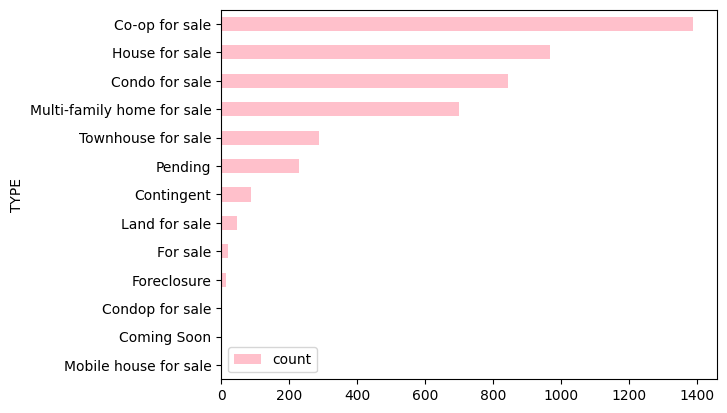

In [10]:
# type
TYPE_count = raw_house_df.TYPE.value_counts()
print('TYPE counts ===', TYPE_count)

pd.DataFrame(TYPE_count).sort_values("count").plot(kind="barh", color = 'pink')

# fig, ax = plt.subplots(figsize=(18, 4))
# fig = sns.countplot(data=raw_house_df, x='TYPE', log=True)
# plt.xticks(rotation=90)
# plt.title('Distribution of property types')
# plt.show()

LOCALITY counts === LOCALITY
New York           2395
New York County     930
Queens County       536
Kings County        442
Bronx County        172
Richmond County      58
United States        37
Queens                6
Brooklyn              6
The Bronx             4
Flatbush              1
Name: count, dtype: int64


<Axes: ylabel='LOCALITY'>

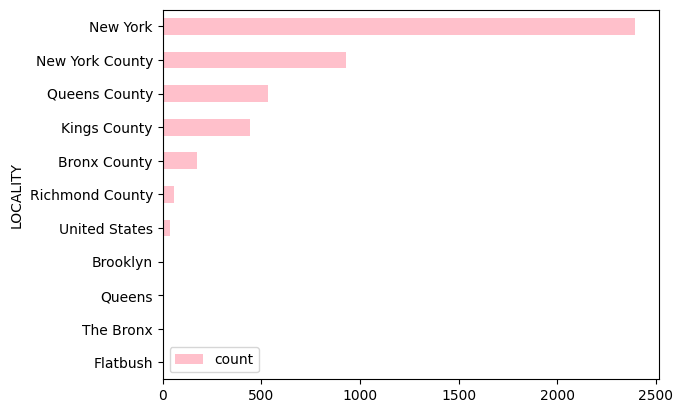

In [11]:
LOCALITY_count = raw_house_df.LOCALITY.value_counts()
print('LOCALITY counts ===', LOCALITY_count)

pd.DataFrame(LOCALITY_count).sort_values("count").plot(kind="barh", color = 'pink')

SUBLOCALITY counts === SUBLOCALITY
New York            967
Kings County        696
Queens County       655
Queens              534
Richmond County     461
Brooklyn            442
Bronx County        291
New York County     271
The Bronx           174
Staten Island        58
Manhattan            21
Flushing              4
Coney Island          3
Riverdale             3
East Bronx            1
Jackson Heights       1
Brooklyn Heights      1
Rego Park             1
Fort Hamilton         1
Dumbo                 1
Snyder Avenue         1
Name: count, dtype: int64


<Axes: ylabel='SUBLOCALITY'>

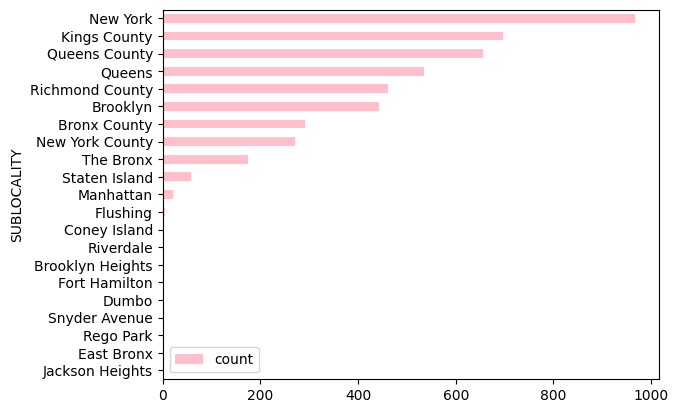

In [13]:

SUBLOCALITY_count = raw_house_df.SUBLOCALITY.value_counts()
print('SUBLOCALITY counts ===', SUBLOCALITY_count)

pd.DataFrame(SUBLOCALITY_count).sort_values("count").plot(kind="barh", color = 'pink')

In [14]:
# STREET_NAME
STREET_NAME_count = raw_house_df.STREET_NAME.value_counts()
print('STREET_NAME_count counts ===', STREET_NAME_count)

# pd.DataFrame(STREET_NAME_count).sort_values("count").plot(kind="barh", color = 'pink')

STREET_NAME_count counts === STREET_NAME
Manhattan          930
Brooklyn           696
Queens             655
Staten Island      461
The Bronx          294
                  ... 
2501                 1
67th Drive           1
Todt Hill            1
Saunders Street      1
Mount Eden           1
Name: count, Length: 174, dtype: int64


In [15]:
note1 = ''' 
前五个街道:
Manhattan           930
Brooklyn            696
Queens              655
Staten Island       461
The Bronx           294

'''


## BATH 有异常值

<Axes: ylabel='BATH'>

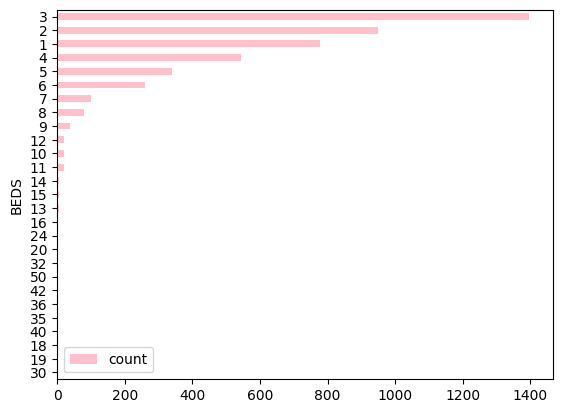

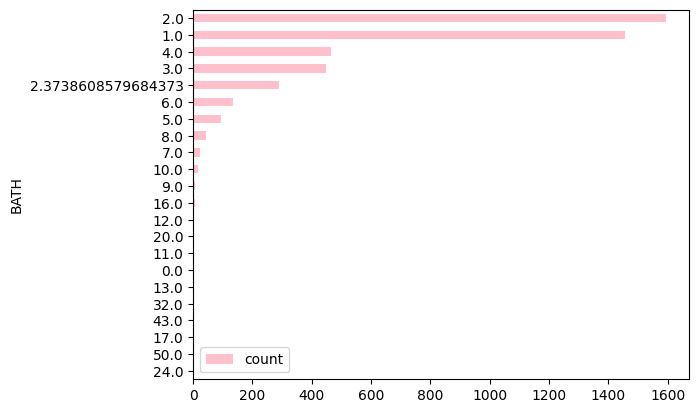

In [16]:
# BEDS, BATH

BEDS_count = raw_house_df.BEDS.value_counts()
# print('BEDS counts ===', BEDS_count)
pd.DataFrame(BEDS_count).sort_values("count").plot(kind="barh", color = 'pink')


BATH_count = raw_house_df.BATH.value_counts()
# print('BATH counts ===', BEDS_count)
pd.DataFrame(BATH_count).sort_values("count").plot(kind="barh", color = 'pink')

## 看下分布

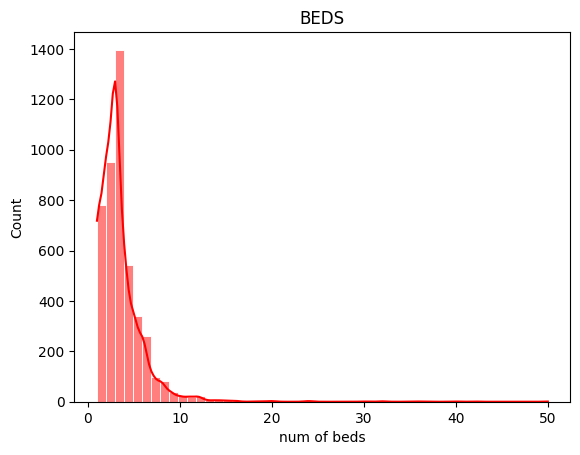

In [17]:
# BED
sns.histplot(raw_house_df['BEDS'], bins=50, color='red', edgecolor='white',kde=True)

plt.xlabel('num of beds')
plt.ylabel('Count')
plt.title('BEDS')
plt.show()

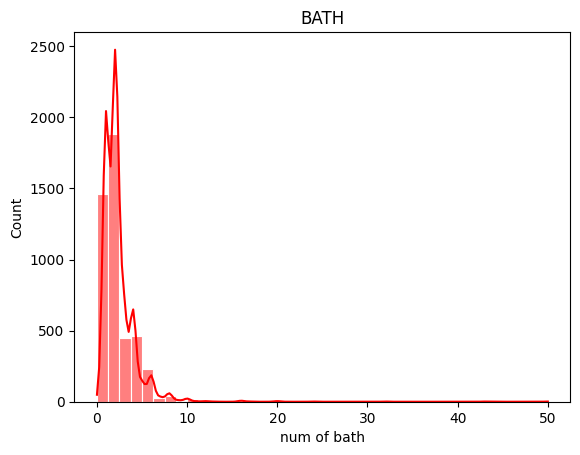

In [18]:
sns.histplot(raw_house_df['BATH'], bins=40, color='red', edgecolor='white', kde=True)

plt.xlabel('num of bath')
plt.ylabel('Count')
plt.title('BATH')
plt.show()

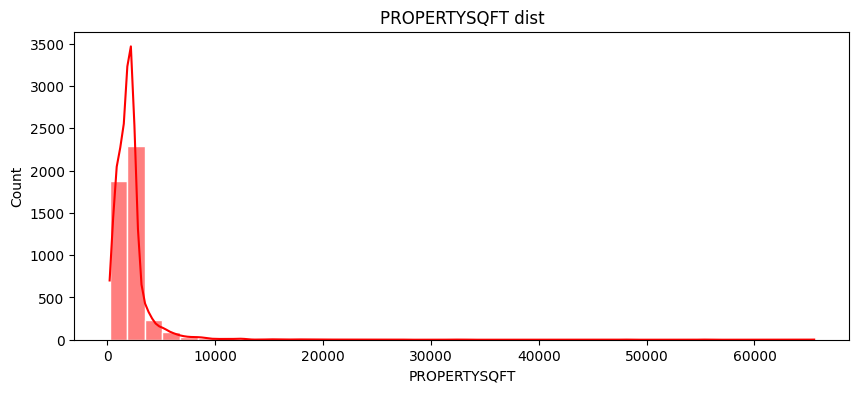

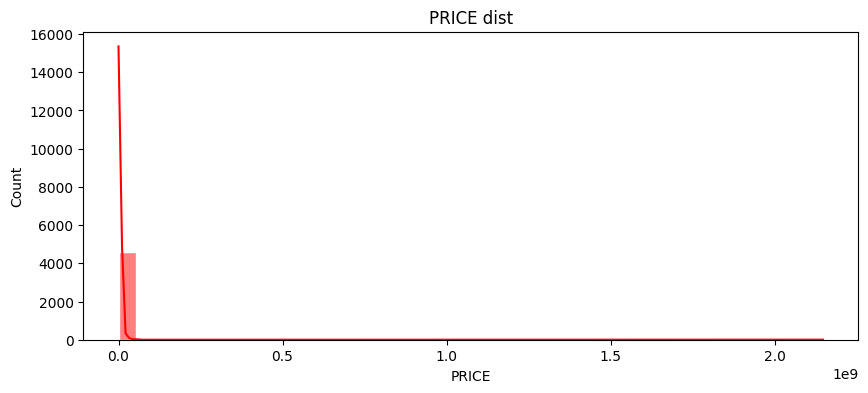

In [19]:
# 面积
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(raw_house_df['PROPERTYSQFT'], bins=40, color='red', edgecolor='white', kde=True)
plt.xlabel('PROPERTYSQFT')
plt.ylabel('Count')
plt.title('PROPERTYSQFT dist')
plt.show()


# 价格
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(raw_house_df['PRICE'], bins=40, color='red', edgecolor='white', kde=True)
plt.xlabel('PRICE')
plt.ylabel('Count')
plt.title('PRICE dist')
plt.show()

## 数值数据的分布和描述性统计量

In [20]:
print('==== dist check ==== ')
display(raw_house_df.describe())

# 看下数值的分布 Calculate skewness for each column
for column in raw_house_df.select_dtypes(include=[np.number]).columns:
    skewness_per_column = raw_house_df[column].skew()
    print(f"Skewness for {column}: {skewness_per_column}")

==== dist check ==== 


,PRICE,BEDS,BATH,PROPERTYSQFT,LATITUDE,LONGITUDE
count,4.587000e+03,4587.000000,4587.000000,4587.000000,4587.000000,4587.000000
mean,2.381172e+06,3.365816,2.377735,2177.712426,40.713932,-73.941584
std,3.206831e+07,2.628808,1.968503,2283.095559,0.087738,0.101276
min,2.494000e+03,1.000000,0.000000,230.000000,40.499546,-74.253033
25%,4.990000e+05,2.000000,1.000000,1200.000000,40.638588,-73.987420
50%,8.250000e+05,3.000000,2.000000,2184.207862,40.726667,-73.949116
75%,1.498500e+06,4.000000,3.000000,2184.207862,40.771913,-73.869455
max,2.147484e+09,50.000000,50.000000,65535.000000,40.912729,-73.702450


Skewness for PRICE: 65.35481192348358
Skewness for BEDS: 5.495813321650833
Skewness for BATH: 7.82905243382857
Skewness for PROPERTYSQFT: 12.348808100744424
Skewness for LATITUDE: -0.08752198915216305
Skewness for LONGITUDE: -0.3920869876425833


In [21]:
# df.rename(columns = {'PRICE':'price', 'BEDS':'beds', 
#                      'BATH':'bath', 'PROPERTYSQFT':'area', 'LOCALITY': 'place', 
#                      'SUBLOCALITY':'sublocality', 'TYPE': "type"}, inplace = True) 
# df.head()

# check outliers
print(raw_house_df['PRICE'].sort_values(ascending=False).head(5))
print(raw_house_df['BEDS'].sort_values(ascending=False).head(5))
print(raw_house_df['BATH'].sort_values(ascending=False).head(5))
print(raw_house_df['PROPERTYSQFT'].sort_values(ascending=False).head(5))

304     2147483647
1        195000000
69        65000000
1075      60000000
141       56000000
Name: PRICE, dtype: int64
1143    50
2653    42
3276    40
2488    36
765     35
Name: BEDS, dtype: int64
1143    50.0
2653    43.0
622     32.0
2564    24.0
1214    20.0
Name: BATH, dtype: float64
4623    65535.0
2146    55300.0
823     48000.0
7       33000.0
3130    32000.0
Name: PROPERTYSQFT, dtype: float64


## 处理异常值 Outliers, abnormal case

In [33]:
# 2147483647
# 195000000

clean_house_df = raw_house_df.copy()
clean_house_df = clean_house_df.drop(clean_house_df[clean_house_df['PRICE'] == 2147483647].index)
clean_house_df = clean_house_df.drop(clean_house_df[clean_house_df['PRICE'] == 195000000].index)

In [34]:
# upper bound 向上取整，处理 2.37
clean_house_df['BATH'] = clean_house_df['BATH'].apply(np.ceil)

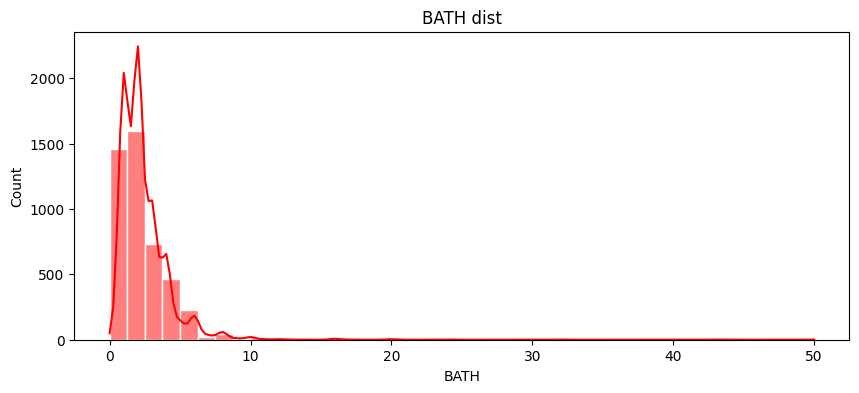

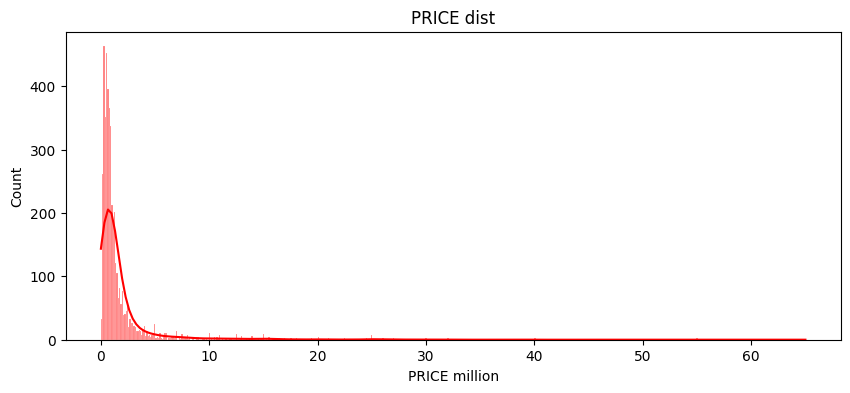

In [24]:

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(clean_house_df['BATH'], bins=40, color='red', edgecolor='white', kde=True)
plt.xlabel('BATH')
plt.ylabel('Count')
plt.title('BATH dist')
plt.show()


# clean_house_df 价格, 转换为 million, auto bin, 房价还是严重右偏 positive skew了
fig, ax = plt.subplots(figsize=(10, 4))
clean_house_df['price_million'] = clean_house_df['PRICE']/1000000
sns.histplot(clean_house_df['price_million'] , bins='auto', color='red', edgecolor='white', kde=True)
plt.xlabel('PRICE million')
plt.ylabel('Count')
plt.title('PRICE dist')
plt.show()

In [25]:
print(clean_house_df['price_million'].describe())

clean_house_df['price_million'].skew()
# NY房间名不虚传，可以看出clean outlier之后仍然 Skewness:7.08451228338595.

count    4585.000000
mean        1.871309
std         4.081827
min         0.002494
25%         0.499000
50%         0.825000
75%         1.495000
max        65.000000
Name: price_million, dtype: float64


np.float64(7.08451228338595)

In [36]:
# 选择需要计算统计值的列
columns_to_describe = ['PRICE', 'BEDS', 'BATH','PROPERTYSQFT','LONGITUDE','LATITUDE']

# 计算均值、标准差、最小值、最大值
summary_stats = clean_house_df[columns_to_describe].agg(['mean', 'std', 'min', 'max'])


summary_stats = summary_stats.map(readable_format)
summary_stats

,PRICE,BEDS,BATH,PROPERTYSQFT,LONGITUDE,LATITUDE
mean,1.87M,3.36,2.41,2.17K,-73.94,40.71
std,4.08M,2.63,1.97,2.27K,0.10,0.09
min,2.49K,1.00,0.00,230.00,-74.25,40.50
max,65.00M,50.00,50.00,65.53K,-73.70,40.91


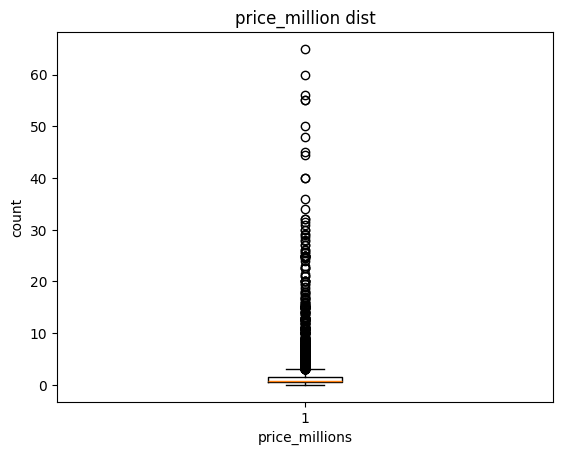

In [26]:
# 箱形图展示
plt.boxplot(clean_house_df['price_million'])
plt.xlabel('price_millions')
plt.ylabel('count')
plt.title('price_million dist')
plt.show()

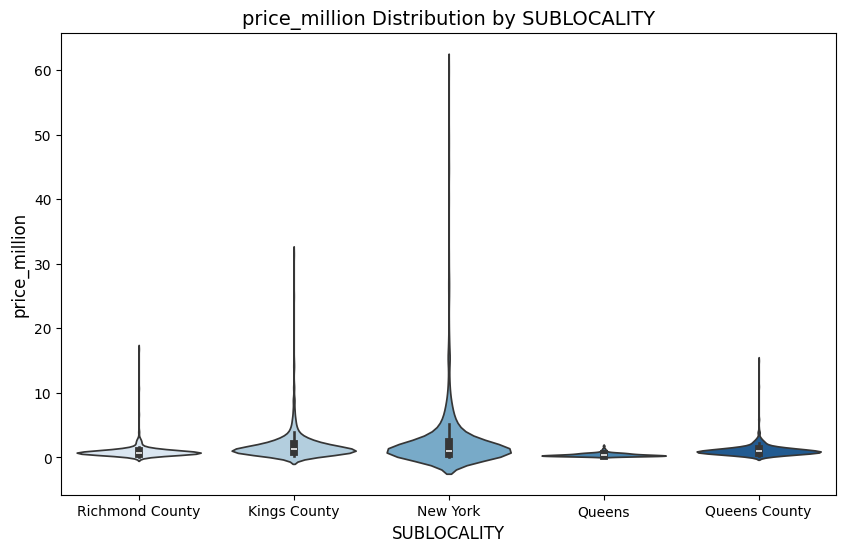

In [27]:
# 细拆地段
'''
SUBLOCALITY counts === SUBLOCALITY
New York            967
Kings County        696
Queens County       655
Queens              534
Richmond County     461
Brooklyn            442
Bronx County        291
New York County     271
The Bronx           174
'''

plt.figure(figsize=(10, 6))
sns.violinplot(x="SUBLOCALITY", y="price_million", 
               data=clean_house_df[clean_house_df['SUBLOCALITY'].isin(['New York','Kings County',
                                                                     'Queens County',
                                                                     'Queens', 'Richmond County'])], 
               palette="Blues")

plt.title("price_million Distribution by SUBLOCALITY", fontsize=14)
plt.xlabel("SUBLOCALITY", fontsize=12)
plt.ylabel("price_million", fontsize=12)
plt.show()

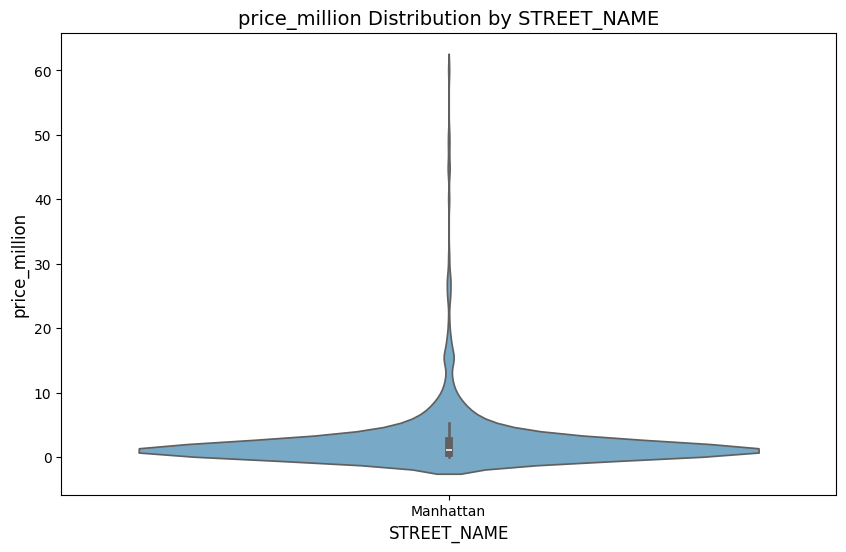

In [28]:
# 只看 Manhattan
plt.figure(figsize=(10, 6))
sns.violinplot(x="STREET_NAME", y="price_million", 
               data=clean_house_df[clean_house_df['STREET_NAME'].isin(['Manhattan'])], 
               palette="Blues")

plt.title("price_million Distribution by STREET_NAME", fontsize=14)
plt.xlabel("STREET_NAME", fontsize=12)
plt.ylabel("price_million", fontsize=12)
plt.show()

## 双变量分析 Bivariate Regression Analysis

In [29]:
le = LabelEncoder()

clean_house_df['locality_encode'] = le.fit_transform(clean_house_df.LOCALITY)
clean_house_df['sublocality_encode'] = le.fit_transform(clean_house_df.SUBLOCALITY)
clean_house_df['type_encode'] = le.fit_transform(clean_house_df.TYPE)

clean_house_df.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,...,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE,price_million,locality_encode,sublocality_encode,type_encode
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.0,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,...,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483,0.315,4,10,2
2,Brokered by Sowae Corp,House for sale,260000,4,2.0,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,...,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109,0.260,4,16,7
3,Brokered by COMPASS,Condo for sale,69000,3,1.0,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,...,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613,0.069,4,12,2
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,3.0,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,...,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856,55.000,4,12,12
5,Brokered by Sowae Corp,House for sale,690000,5,2.0,4004.0,584 Park Pl,"Brooklyn, NY 11238","584 Park PlBrooklyn, NY 11238",United States,...,Kings County,Brooklyn,Park Place,"584 Park Pl, Brooklyn, NY 11238, USA",40.674363,-73.958725,0.690,4,9,7


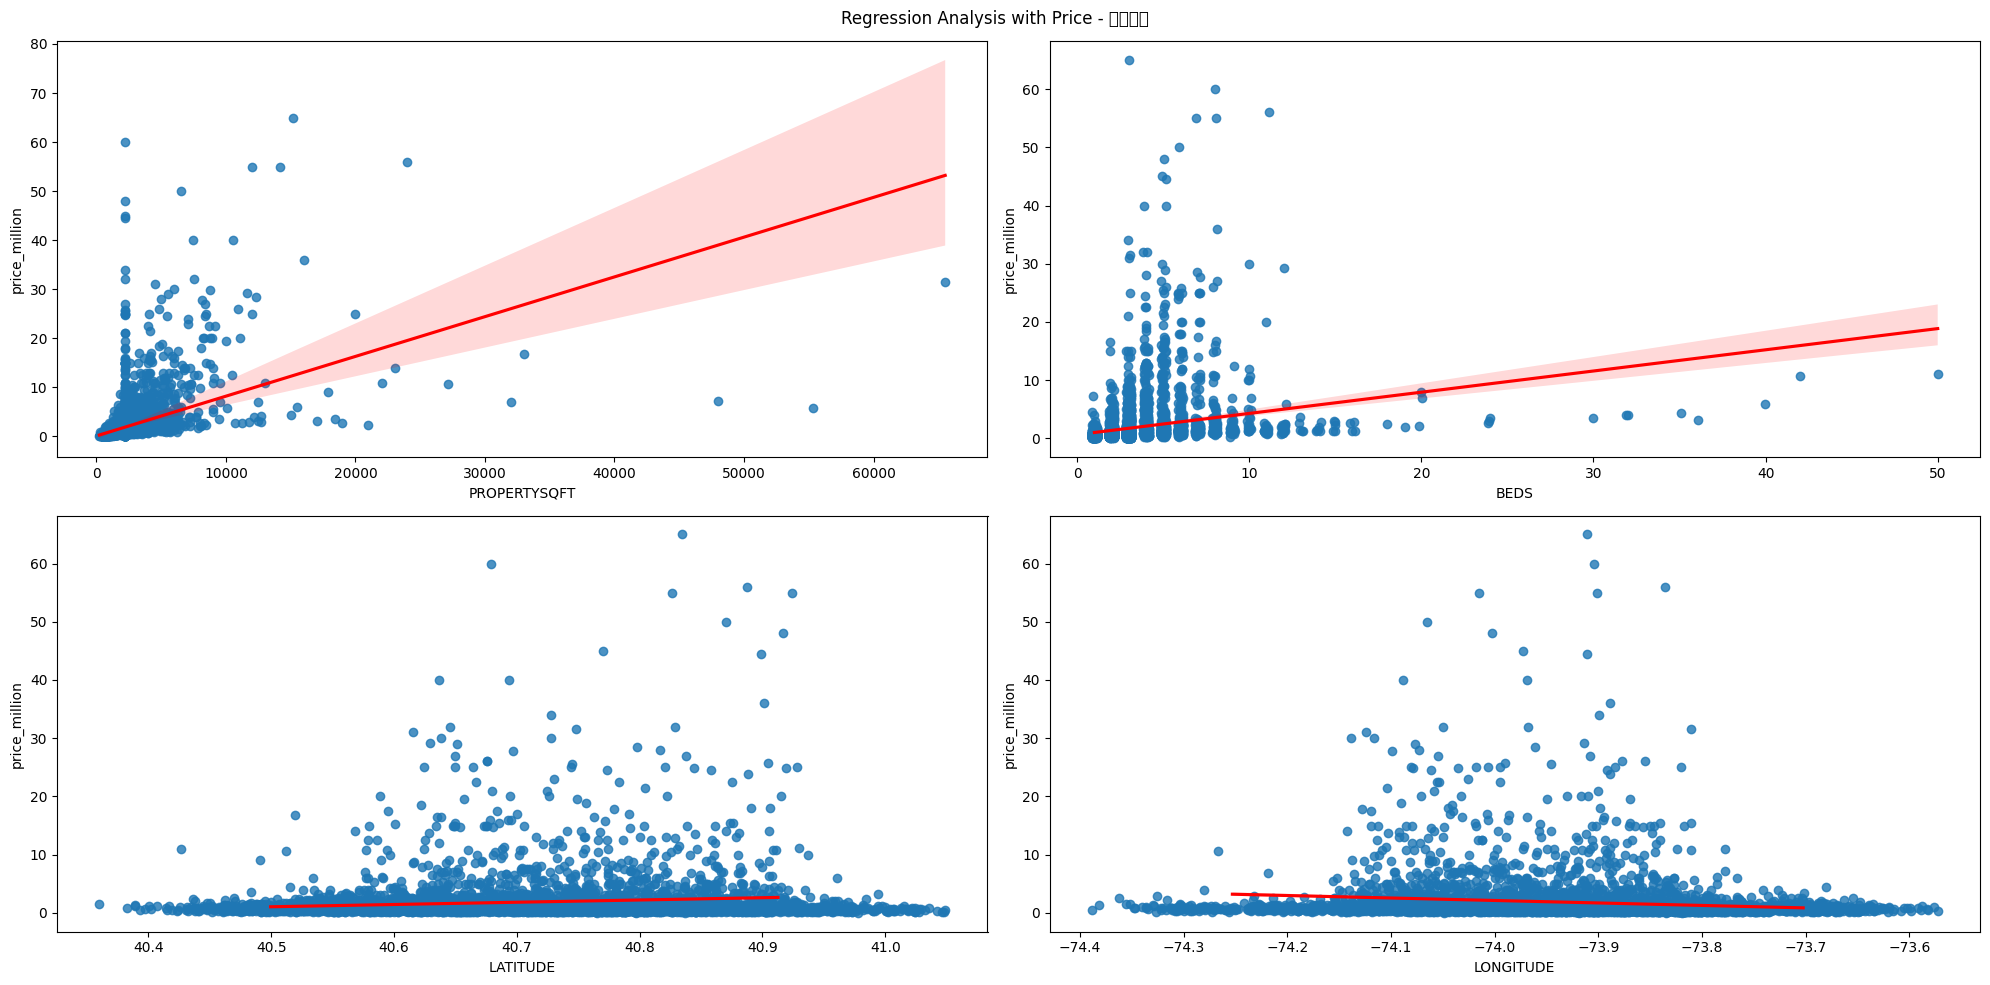

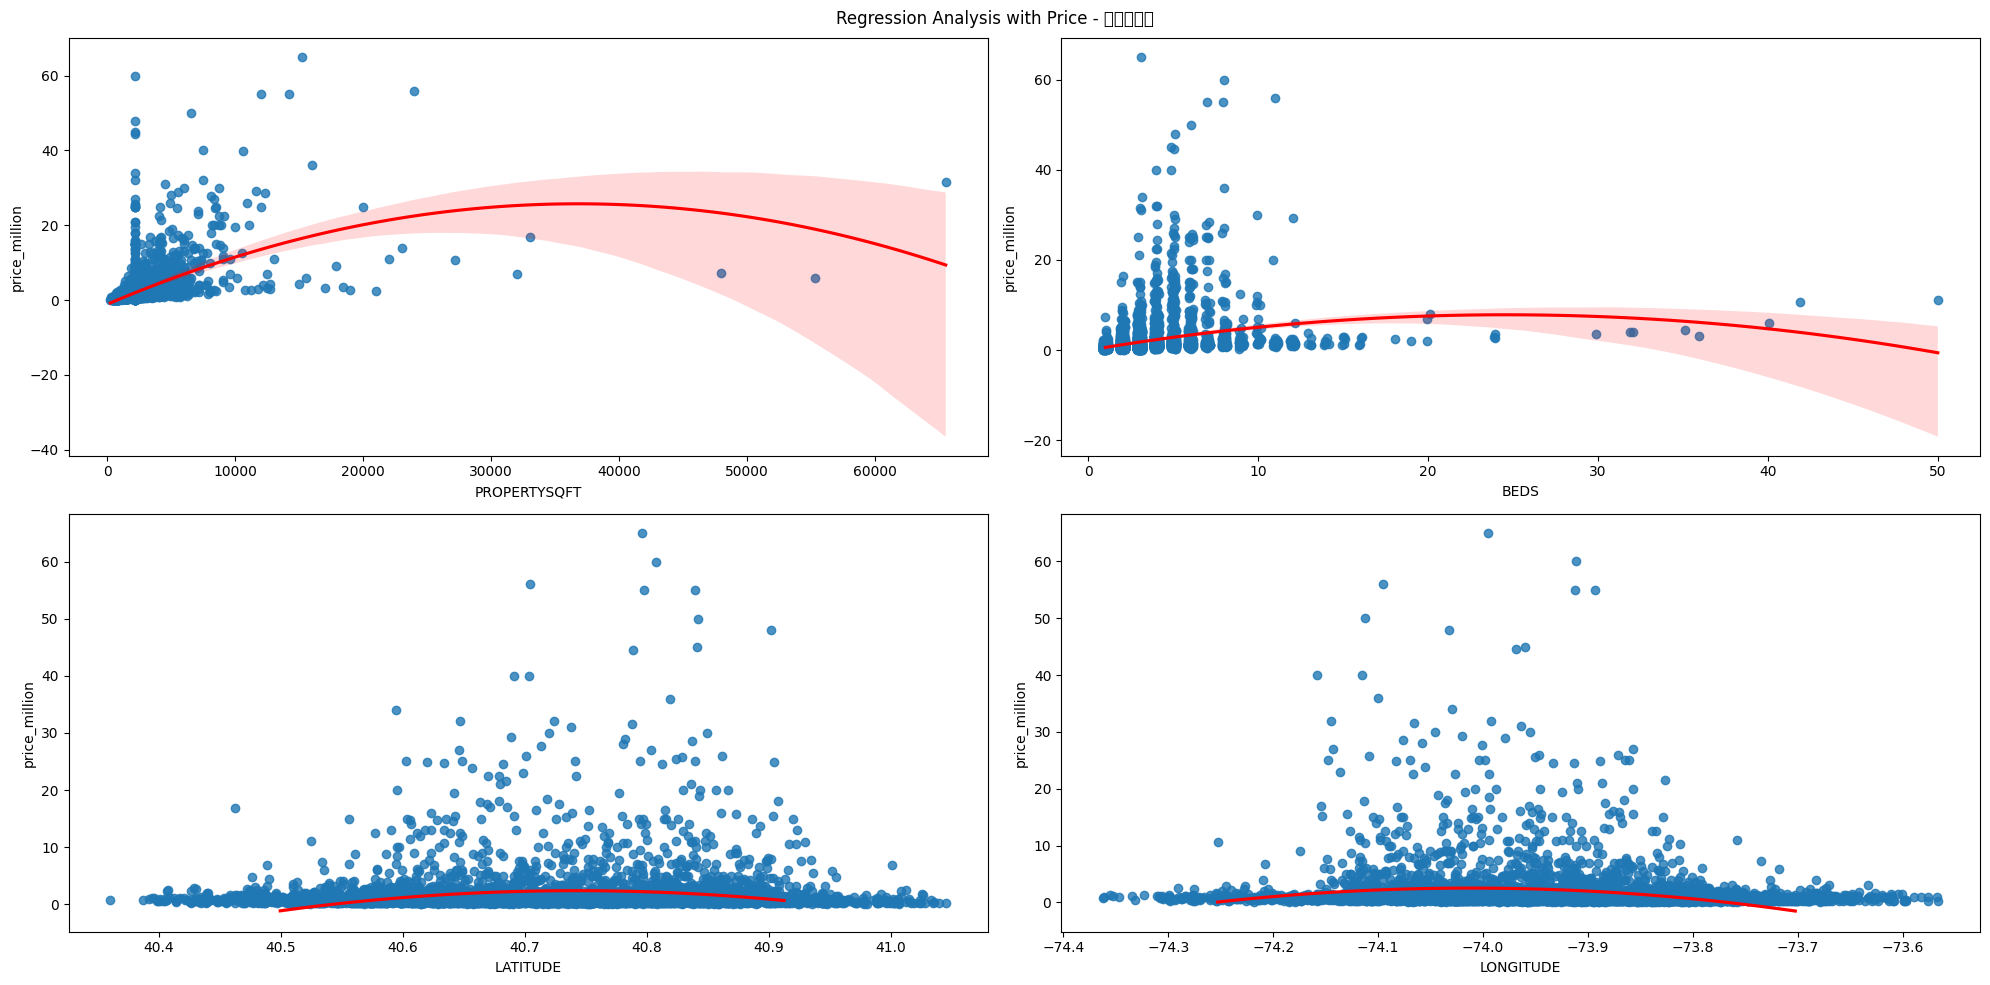

In [30]:

fig = plt.figure(figsize=(20, 10))
fig1 = fig.add_subplot(221); sns.regplot(data=clean_house_df, x="PROPERTYSQFT", y="price_million", x_jitter=.15, line_kws=dict(color="r"),)
plt.ticklabel_format(style = 'plain')
fig2 = fig.add_subplot(222); sns.regplot(data=clean_house_df, x="BEDS", y="price_million", x_jitter=.15, line_kws=dict(color="r"),)
plt.ticklabel_format(style = 'plain')
fig3 = fig.add_subplot(223); sns.regplot(data=clean_house_df, x="LATITUDE", y="price_million", x_jitter=.15, line_kws=dict(color="r"),)
plt.ticklabel_format(style = 'plain')
fig4 = fig.add_subplot(224); sns.regplot(data=clean_house_df, x="LONGITUDE", y="price_million", x_jitter=.15, line_kws=dict(color="r"),)
plt.ticklabel_format(style = 'plain')
plt.suptitle('Regression Analysis with Price - 线性回归')
plt.tight_layout()
plt.show()


fig = plt.figure(figsize=(20, 10))
fig1 = fig.add_subplot(221); sns.regplot(data=clean_house_df, x="PROPERTYSQFT",order=2, y="price_million", x_jitter=.15, line_kws=dict(color="r"),)
plt.ticklabel_format(style = 'plain')
fig2 = fig.add_subplot(222); sns.regplot(data=clean_house_df, x="BEDS", y="price_million",order=2, x_jitter=.15, line_kws=dict(color="r"),)
plt.ticklabel_format(style = 'plain')
fig3 = fig.add_subplot(223); sns.regplot(data=clean_house_df, x="LATITUDE", y="price_million",order=2, x_jitter=.15, line_kws=dict(color="r"),)
plt.ticklabel_format(style = 'plain')
fig4 = fig.add_subplot(224); sns.regplot(data=clean_house_df, x="LONGITUDE", y="price_million",order=2, x_jitter=.15, line_kws=dict(color="r"),)
plt.ticklabel_format(style = 'plain')
plt.suptitle('Regression Analysis with Price - 二阶多项式')
plt.tight_layout()
plt.show()

# 可以尝试对数 logx=True

# Modeling


In [151]:
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.neighbors import NearestNeighbors
import xgboost as xgb

In [154]:
clean_house_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4585 entries, 0 to 4800
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4585 non-null   object 
 1   TYPE                         4585 non-null   object 
 2   PRICE                        4585 non-null   int64  
 3   BEDS                         4585 non-null   int64  
 4   BATH                         4585 non-null   float64
 5   PROPERTYSQFT                 4585 non-null   float64
 6   ADDRESS                      4585 non-null   object 
 7   STATE                        4585 non-null   object 
 8   MAIN_ADDRESS                 4585 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4585 non-null   object 
 10  LOCALITY                     4585 non-null   object 
 11  SUBLOCALITY                  4585 non-null   object 
 12  STREET_NAME                  4585 non-null   object 
 13  LONG_NAME              

In [ ]:
# model = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=400)
# model.fit(x, y)

# importance = model.feature_importances_
# feature_names = x.columns

# importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
# importance_df = importance_df.sort_values(by='Importance', ascending=False)
# importance_df = importance_df.set_index('Feature') 
# print(importance_df)


# importance_df.sort_values("Importance").plot(kind="barh", color = 'pink')
# plt.title('Feature Importance')
# plt.show()

In [157]:
feature_df = clean_house_df[['price_million', 'BEDS', 'BATH', 'PROPERTYSQFT', 'LONGITUDE', 'LATITUDE']]
feature_df.head()

X = feature_df.drop(['price_million'], axis=1)
y = feature_df['price_million']

In [159]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.columns)
print(X_test.shape, X_train.shape)

Index(['BEDS', 'BATH', 'PROPERTYSQFT', 'LONGITUDE', 'LATITUDE'], dtype='object')
(917, 5) (3668, 5)


In [ ]:
X_encoded = pd.get_dummies(X, columns=['bath',
                                       'beds'])

X_encoded.head()

## 3.3 Splitting data into train and test

In [167]:
xgb_v1 = xgb.XGBRegressor(objective="reg:squarederror",
                            # missing=None,
                            seed=42)
xgb_v1.fit(X_train,
            y_train,
            verbose=True,
            early_stopping_rounds=20,
            eval_metric='rmse',
            eval_set=[(X_test, y_test)])

[0]	validation_0-rmse:3.49692
[1]	validation_0-rmse:3.26052
[2]	validation_0-rmse:3.13901
[3]	validation_0-rmse:3.11614
[4]	validation_0-rmse:3.03602
[5]	validation_0-rmse:3.00615
[6]	validation_0-rmse:2.97829
[7]	validation_0-rmse:2.92086
[8]	validation_0-rmse:2.79038
[9]	validation_0-rmse:2.74843
[10]	validation_0-rmse:2.73519
[11]	validation_0-rmse:2.66429
[12]	validation_0-rmse:2.60716
[13]	validation_0-rmse:2.58352
[14]	validation_0-rmse:2.59199
[15]	validation_0-rmse:2.58269
[16]	validation_0-rmse:2.58444
[17]	validation_0-rmse:2.54299
[18]	validation_0-rmse:2.54044
[19]	validation_0-rmse:2.53538
[20]	validation_0-rmse:2.53563
[21]	validation_0-rmse:2.52746
[22]	validation_0-rmse:2.51942
[23]	validation_0-rmse:2.51238
[24]	validation_0-rmse:2.50988
[25]	validation_0-rmse:2.46751
[26]	validation_0-rmse:2.45385
[27]	validation_0-rmse:2.45937
[28]	validation_0-rmse:2.45798
[29]	validation_0-rmse:2.46058
[30]	validation_0-rmse:2.45939
[31]	validation_0-rmse:2.47010
[32]	validation_0-

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

              Importance
Feature                 
PROPERTYSQFT    0.431649
LATITUDE        0.183398
BATH            0.153695
LONGITUDE       0.151015
BEDS            0.080243


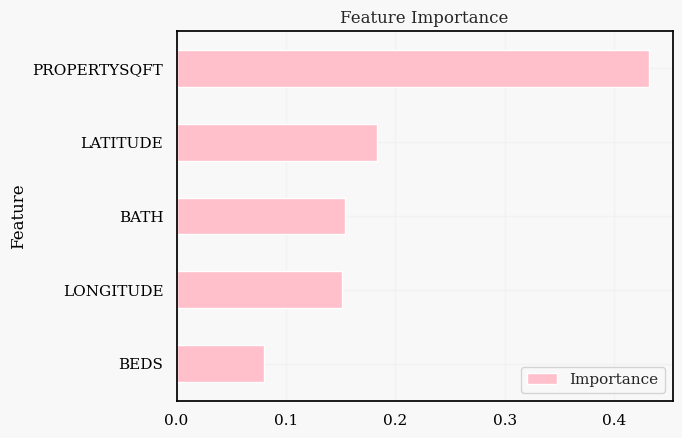

In [163]:
# 获取特征重要性
importance = xgb_v1.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
# remove index 1,2,3
importance_df = importance_df.set_index('Feature') 
print(importance_df)

importance_df.sort_values("Importance").plot(kind="barh", color = 'pink')
plt.title('Feature Importance')
plt.show()

# 4. Predictions

In [180]:
y_preds = xgb_v1.predict(X_test)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error 

print('mean_squared_error=', mean_squared_error(y_test, y_preds))
print('mean_absolute_percentage_error=',mean_absolute_percentage_error(y_test, y_preds))
print('mean_absolute_error=',mean_absolute_error(y_test, y_preds))

mean_squared_error= 5.79536287484734
mean_absolute_percentage_error= 0.482996100412528
mean_absolute_error= 0.7107496582143182


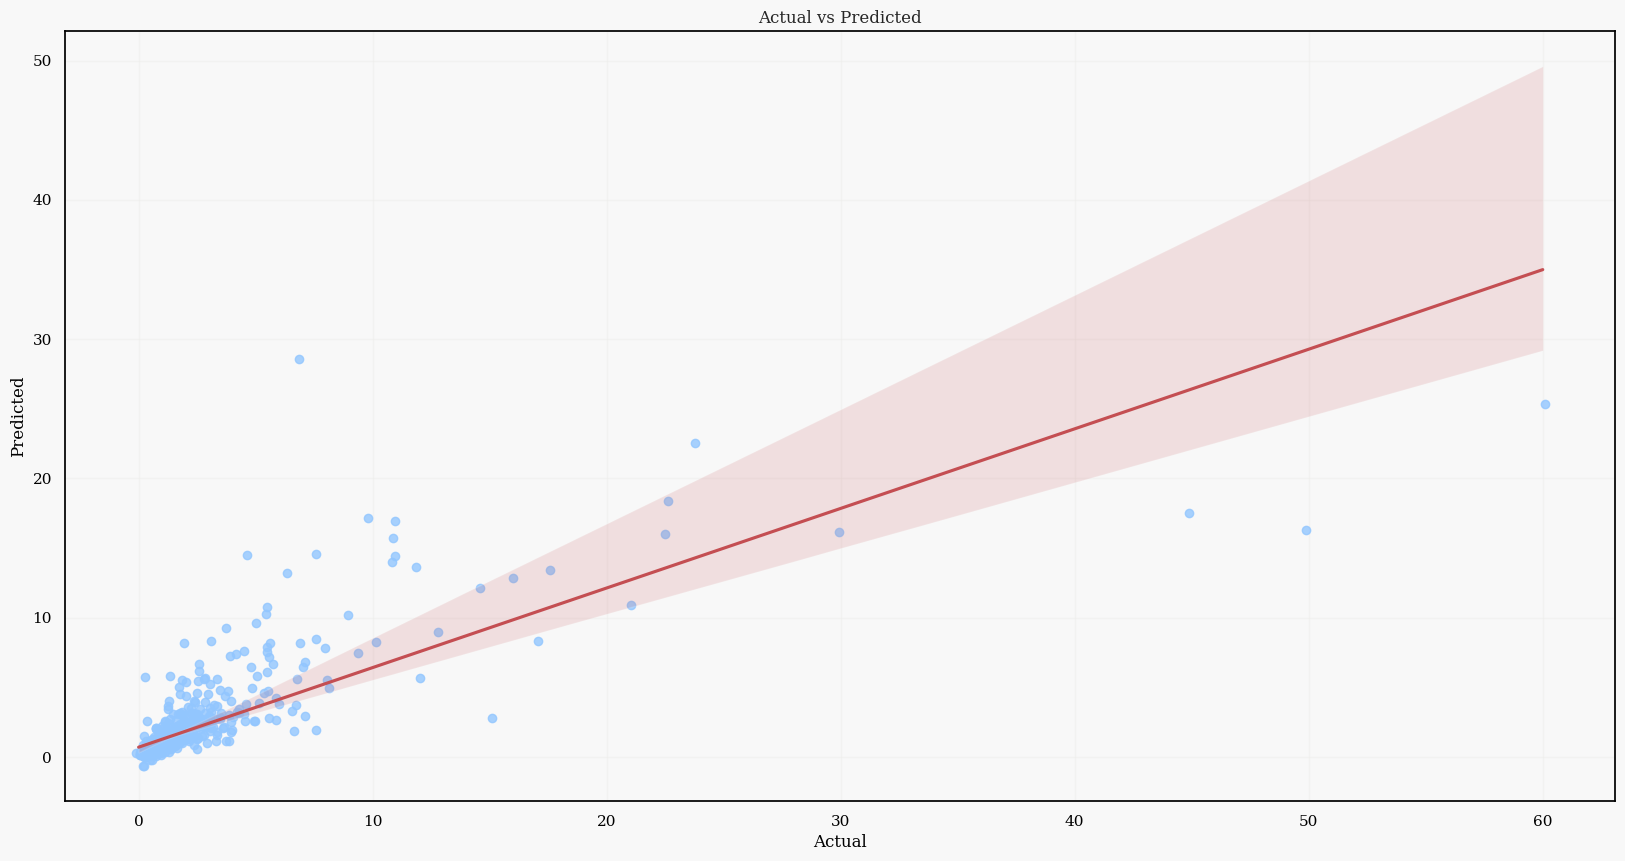

In [181]:
fig = plt.figure(figsize=(20, 10))
sns.regplot(data=feature_df, x=y_test, y=y_preds, x_jitter=.15, line_kws=dict(color="r"),)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.ticklabel_format(style = 'plain')

mean_squared_error= 5.79536287484734
mean_absolute_percentage_error= 0.482996100412528
mean_absolute_error= 0.7107496582143182


In [176]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


rgr = RandomForestRegressor(
    n_estimators=100,  # 树的数量
    criterion='squared_error',  # 分裂标准（MSE）
    max_depth=None,    # 树的最大深度
    min_samples_split=2,
    random_state=42
)

rgr.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

mean_squared_error= 7.076492318745589
mean_absolute_percentage_error= 0.4232305565694874
mean_absolute_error= 0.6941840301968895


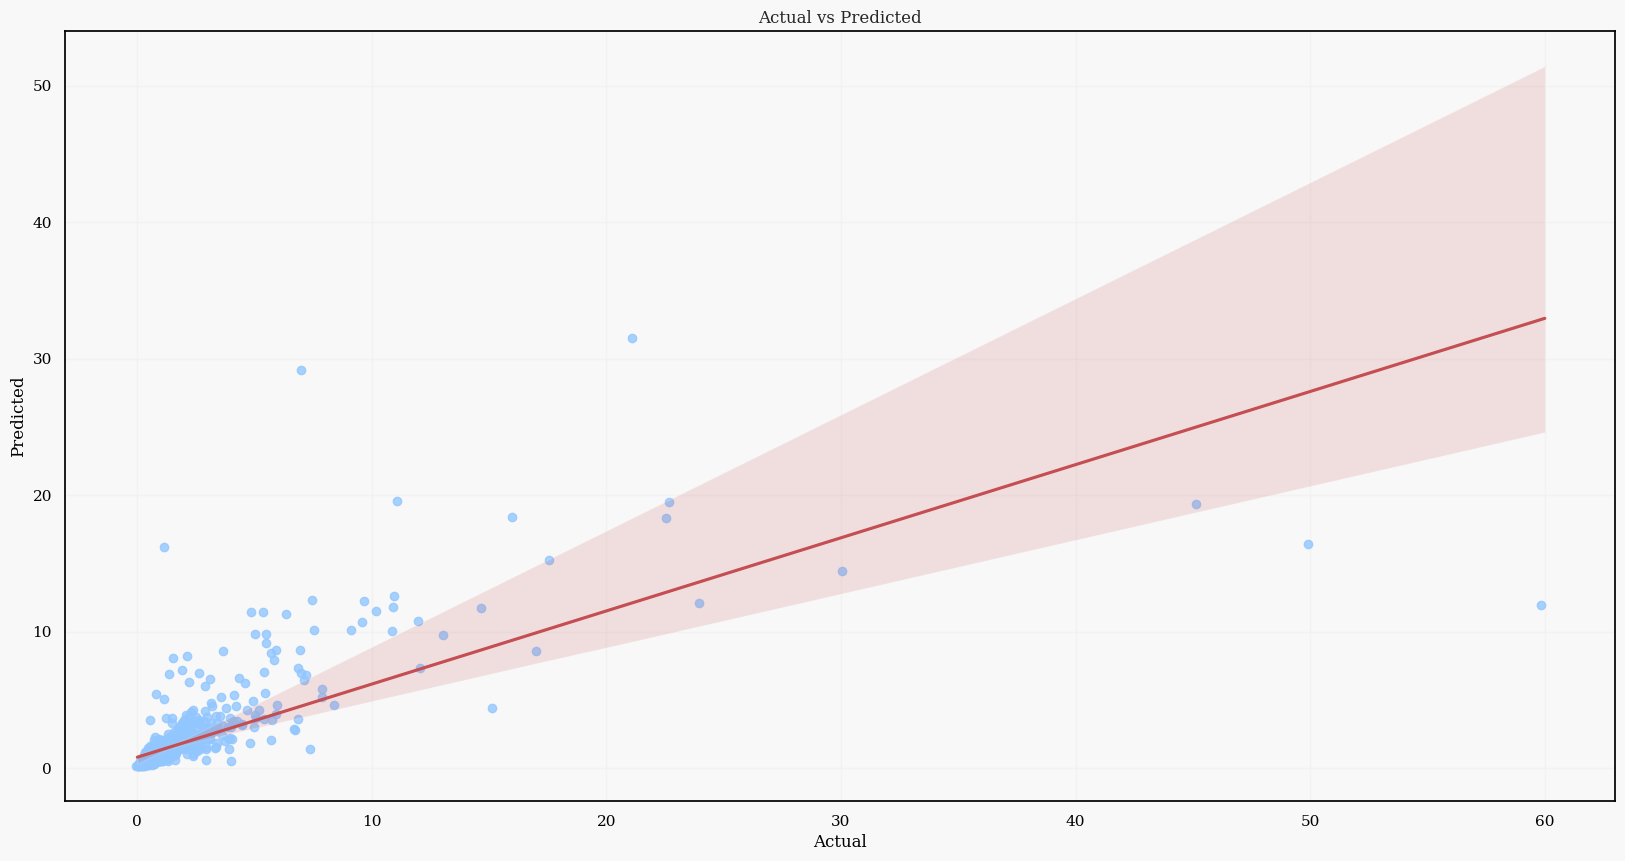

In [185]:
# from sklearn.metrics import mean_squared_error
# from sklearn.metrics import mean_absolute_percentage_error
# from sklearn.metrics import mean_absolute_error 

y_pred2 = rgr.predict(X_test)
print('mean_squared_error=', mean_squared_error(y_test, y_pred2))
print('mean_absolute_percentage_error=',mean_absolute_percentage_error(y_test, y_pred2))
print('mean_absolute_error=',mean_absolute_error(y_test, y_pred2))

fig = plt.figure(figsize=(20, 10))
sns.regplot(data=feature_df, x=y_test, y=y_pred2, x_jitter=.15, line_kws=dict(color="r"),)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.ticklabel_format(style = 'plain')

# RandomForestRegressor is better

In [184]:
# from catboost import CatBoostRegressor
# model = CatBoostRegressor(
#     iterations=1000,  # Number of boosting rounds
#     learning_rate=0.1,
#     depth=6,
#     loss_function='RMSE',  # Regression metric
#     verbose=100,  # Print training progress every 100 iterations
#     random_state=42
# )

# autogluon
# from autogluon.tabular import TabularDataset, TabularPredictor
# train_ds = TabularDataset(autogluon_train)
# label = 'box_office_million'
# save_path = 'work_dir'
# predictor = TabularPredictor(label=label, path=save_path).fit(train_ds)
# display(predictor.leaderboard(
#     test_data, 
#     extra_metrics = ['root_mean_squared_error', 'mean_squared_error', 'mean_absolute_error', 
#                      'median_absolute_error', 'mean_absolute_percentage_error', 'r2'], silent=True))
# predictor.evaluate(test_data)